## Malaria Detection System using CNN

In [2]:
!pip install -U "protobuf>=6.31.1" importlib_resources

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Normalization
from tensorflow.keras.layers import BatchNormalization

In [4]:
tfds.list_builders()[:5]

['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset']

## Data Processing

In [5]:
dataset, dataset_info = tfds.load(
                                  'malaria',
                                  with_info=True,
                                  # split=['train[:80%]','train[80%:90%]','train[90%:]'],
                                  shuffle_files=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.4THO7H_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


I0000 00:00:1791034491.715351     152 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791034491.718082     152 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
Dataset_size=len(dataset['train'])

In [7]:
def split(ds, train_ratio, val_ratio):
    n = len(ds)
    train_n = int(train_ratio * n)
    val_n = int(val_ratio * n)

    train_ds = ds.take(train_n)
    rest = ds.skip(train_n)
    val_ds = rest.take(val_n)
    test_ds = rest.skip(val_n)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split(dataset['train'], 0.8, 0.1)

print(len(train_ds), len(val_ds), len(test_ds))

22046 2755 2757


## Data Visualization

In [8]:
def getLabel(label):
  if label == 0:
    return "Parasitized"
  else:
    return "Uninfected"

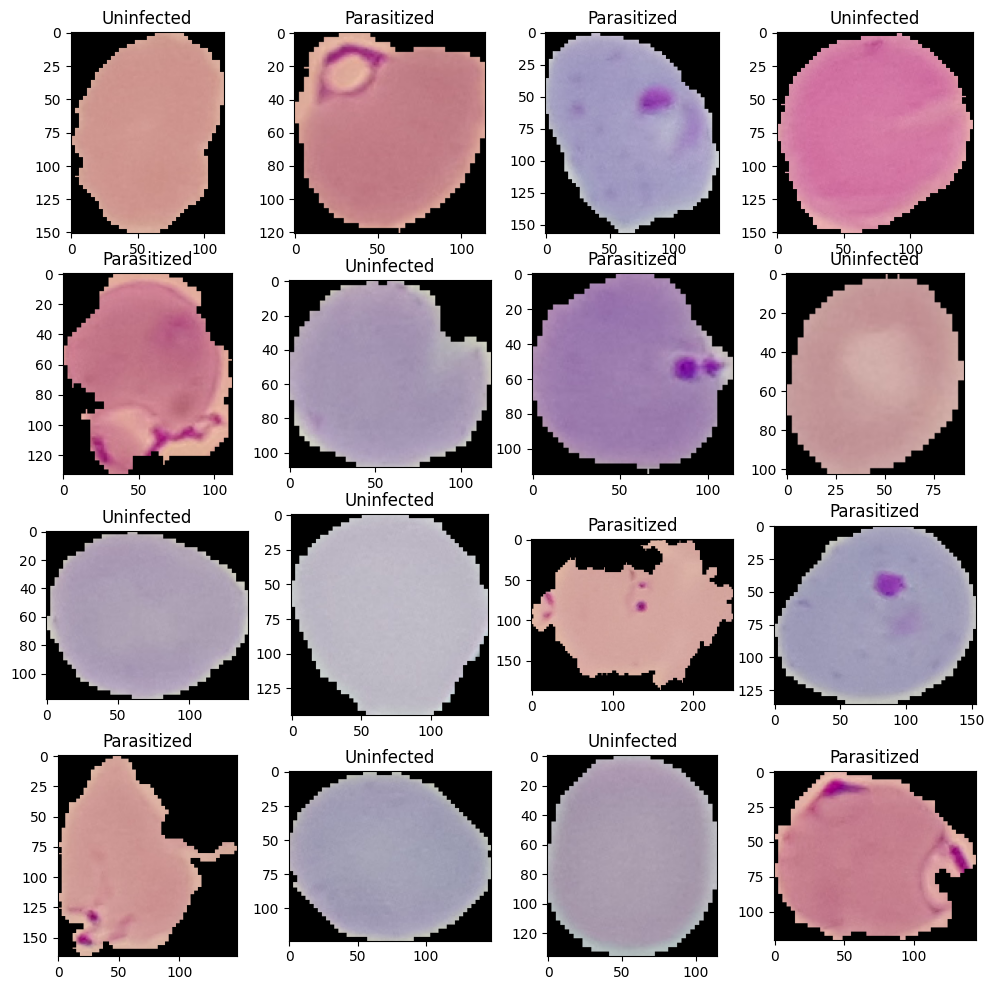

In [10]:
plt.figure(figsize=(12,12))
for i,sample in enumerate(train_ds.take(16)):
  plt.subplot(4,4,i+1)
  plt.imshow(sample['image'])
  plt.title(getLabel(sample['label'].numpy()))

## Rescaling The Images

In [11]:
IM_size=224
BATCH_SIZE=32

In [12]:
def resize_rescale(input):
  image = tf.image.resize(input['image'],(IM_size,IM_size))/255.
  return image,input['label']

In [13]:
train_dataset = train_ds.map(resize_rescale).shuffle(buffer_size=1000, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_ds.map(resize_rescale).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_ds.map(resize_rescale).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [14]:
for image,label in test_dataset.take(1):
  print(image.shape)

(32, 224, 224, 3)


In [15]:
np.unique(image)

array([0.0000000e+00, 1.7794440e-05, 1.9326864e-05, ..., 9.2034698e-01,
       9.2130208e-01, 9.2148435e-01], dtype=float32)

## Model Creation

In [31]:
from tensorflow.python.distribute.cross_device_ops import kernels
model = tf.keras.Sequential([
    layers.Input(shape=(IM_size,IM_size,3)),

    ## Conv2d Layer
    layers.Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    layers.MaxPool2D(pool_size=(2,2),strides=None),

    ## Conv2d Layer
    layers.Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    layers.MaxPool2D(pool_size=(2,2),strides=None),

    ## Flatten Layer
    layers.Flatten(),

    ## Dense Layer
    Dense(100,activation='relu'),
    BatchNormalization(),
    Dense(10,activation='relu'),
    BatchNormalization(),
    Dense(1,activation='sigmoid')
])
model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    )

In [39]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    verbose=1
)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.9939 - loss: 0.0186 - precision: 0.9937 - recall: 0.9941 - val_accuracy: 0.8857 - val_loss: 0.4904 - val_precision: 0.9425 - val_recall: 0.8240
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9935 - loss: 0.0214 - precision: 0.9932 - recall: 0.9937 - val_accuracy: 0.9354 - val_loss: 0.6619 - val_precision: 0.9093 - val_recall: 0.9692
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9951 - loss: 0.0159 - precision: 0.9946 - recall: 0.9957 - val_accuracy: 0.9125 - val_loss: 0.6559 - val_precision: 0.9594 - val_recall: 0.8639
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9938 - loss: 0.0190 - precision: 0.9936 - recall: 0.9941 - val_accuracy: 0.9383 - val_loss: 0.4293 - val_precision: 0.9341 - val_recall: 0.9448
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9942 - loss: 0.0177 - precision: 0.9938 - recall: 0.9946 - val_accuracy: 0.9390 - va

In [34]:
model.evaluate(test_dataset)

87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9402 - loss: 0.3488


[0.3487677276134491, 0.9401523470878601]

In [44]:
metrics=history.history

In [45]:
print(metrics.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


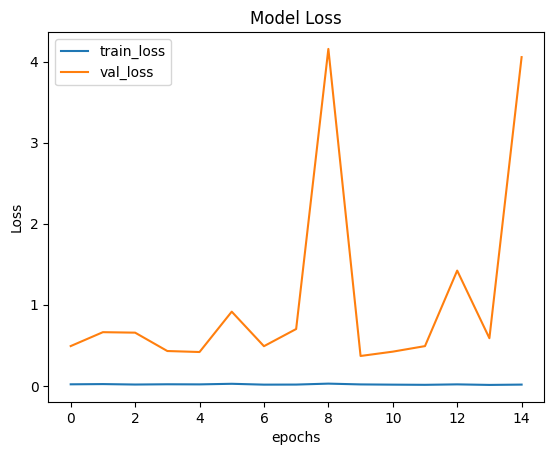

In [50]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend(['train_loss','val_loss'])
plt.show()

In [51]:
model.save('Malaira_detection_System.keras')